# From Red Flags to Detection Rules: An LLM-driven Pipeline for Real-Time GOOSE Intrusion Detection and Prevention

> **Autores:** Lucas A. Martins¹*, Silvio E. Quincozes¹²  
> ¹ Universidade Federal de Uberlândia (UFU) – Uberlândia, Brasil  
> ² Universidade Federal do Pampa (UNIPAMPA) – Alegrete, Brasil  
> `{lucas.martins, sequincozes}@ufu.br`

---

## Resumo

Sistemas de Detecção de Intrusão (IDS) baseados em especificação são amplamente utilizados em subestações IEC 61850, mas dependem de regras criadas manualmente por especialistas. Este notebook apresenta um **pipeline orientado por LLM** que automatiza a geração de regras de detecção para detecção e prevenção de intrusões GOOSE em tempo real.

A abordagem utiliza amostras de comunicação rotuladas para identificar *red flags*, que são transformadas em regras de detecção de intrusão executáveis. A prova de conceito usa o **dataset ERENO** e demonstra que as regras geradas detectam comportamentos anômalos com baixo overhead operacional.

---
## 1. Instalação e Configuração do Ambiente

In [27]:
# 1.1 Importacao de todas as bibliotecas necessarias
import subprocess
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
from datetime import datetime
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Configuracoes
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Todos os imports realizados com sucesso!")
print(f"Python version: {sys.version}")

Todos os imports realizados com sucesso!
Python version: 3.14.3 (main, Feb  4 2026, 00:00:00) [GCC 15.2.1 20260123 (Red Hat 15.2.1-7)]


---
## 2. Ingestao de Dados (ERENO)

In [28]:
# 2.1 Localizar e carregar o dataset

# Tentar diferentes caminhos possiveis
possible_paths = [
    Path("small_dataset/ERENO-2.0-1K_test.csv"),
    Path("small_dataset/test.csv"),
    Path("ERENO-2.0-1K_test.csv"),
    Path("test.csv"),
]

DATASET_PATH = None
for path in possible_paths:
    if path.exists():
        DATASET_PATH = path
        break

if DATASET_PATH is None:
    print("Dataset real nao encontrado. Criando dataset de exemplo para demonstracao...")
    
    # Criar dataset sintetico para teste
    np.random.seed(42)
    
    classes = ['normal', 'grayhole', 'high_StNum', 'injection', 'inverse_replay', 
               'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 
               'random_replay']
    
    n_samples = 207
    data = []
    
    for i in range(n_samples):
        cls = np.random.choice(classes)
        
        # Valores base por classe
        if cls == 'normal':
            stnum = np.random.randint(1, 100)
            sqnum = np.random.randint(1, 50)
            stdiff = np.random.uniform(-2, 2)
            sqdiff = np.random.uniform(-2, 2)
            timestampdiff = np.random.uniform(-0.1, 0.1)
            tdiff = np.random.uniform(-0.1, 0.1)
        elif cls == 'high_StNum':
            stnum = np.random.randint(50000, 60000)
            sqnum = np.random.randint(1, 50)
            stdiff = np.random.uniform(1000, 2000)
            sqdiff = np.random.uniform(-2, 2)
            timestampdiff = np.random.uniform(-0.1, 0.1)
            tdiff = np.random.uniform(-0.1, 0.1)
        elif cls == 'grayhole':
            stnum = 0
            sqnum = np.random.randint(1, 50)
            stdiff = np.random.uniform(-2, 2)
            sqdiff = np.random.uniform(-2, 2)
            timestampdiff = np.random.uniform(-0.1, 0.1)
            tdiff = np.random.uniform(-0.1, 0.1)
        else:
            stnum = np.random.randint(1, 50000)
            sqnum = np.random.randint(1, 50)
            stdiff = np.random.uniform(-20, -5) if np.random.random() > 0.5 else np.random.uniform(5, 20)
            sqdiff = np.random.uniform(-20, -5) if np.random.random() > 0.5 else np.random.uniform(5, 20)
            timestampdiff = np.random.uniform(0.5, 2)
            tdiff = np.random.uniform(0.5, 2)
        
        data.append({
            'class': cls,
            'StNum': stnum,
            'SqNum': sqnum,
            'stDiff': stdiff,
            'sqDiff': sqdiff,
            'timestampDiff': timestampdiff,
            'tDiff': tdiff
        })
    
    df = pd.DataFrame(data)
    print(f"Dataset de exemplo criado com {len(df)} amostras")
else:
    # Carregar dataset real
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset real carregado de: {DATASET_PATH.resolve()}")

print(f"Dataset: {len(df)} amostras, {df.shape[1]} features\n")
print("Distribuicao das classes:")
class_counts = df['class'].value_counts()
for cls, count in class_counts.items():
    print(f"  - {cls}: {count} amostras ({count/len(df)*100:.1f}%)")

print("\nPrimeiras linhas:")
display(df.head())

Dataset real carregado de: /home/lucas/Documentos/Mestrado/small_dataset/ERENO-2.0-1K_test.csv
Dataset: 207 amostras, 52 features

Distribuicao das classes:
  - poisoned_high_rate: 23 amostras (11.1%)
  - grayhole: 23 amostras (11.1%)
  - inverse_replay: 23 amostras (11.1%)
  - masquerade_fake_fault: 23 amostras (11.1%)
  - masquerade_fake_normal: 23 amostras (11.1%)
  - normal: 23 amostras (11.1%)
  - high_StNum: 23 amostras (11.1%)
  - random_replay: 23 amostras (11.1%)
  - injection: 23 amostras (11.1%)

Primeiras linhas:


,Time,isbA,isbB,isbC,vsbA,vsbB,vsbC,isbARmsValue,isbBRmsValue,isbCRmsValue,...,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,1091.2385,-0.039044,-0.042865,0.079455,-0.042158,0.097473,-0.055315,0.046849,0.050634,0.050901,...,-80.0,0.0,1.0,0.0,0.0,0.116166,-805.919857,707.598591,0.000180,poisoned_high_rate
1,2613.6100,0.254370,-0.280967,-0.033508,-0.087483,-0.018146,0.090788,0.778014,0.109190,0.377037,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.004000,0.000203,grayhole
2,4164.5510,0.532722,0.082284,-0.332637,0.086148,-0.019887,-0.074053,0.945089,0.267017,0.246929,...,0.0,0.0,0.0,0.0,0.0,0.003353,0.000000,1318.944666,0.000195,inverse_replay
3,1688.0143,0.024797,0.042299,-0.066042,0.017338,-0.032020,0.014680,0.014291,0.025667,0.033056,...,1.0,0.0,0.0,0.0,0.0,0.004000,0.000000,0.008000,0.000028,masquerade_fake_fault
4,58947.7730,0.034577,-0.149848,0.067955,-0.096449,0.034230,0.062022,0.108773,0.106597,0.074481,...,0.0,0.0,0.0,0.0,0.0,6.438091,0.000000,58564.134007,0.000684,poisoned_high_rate


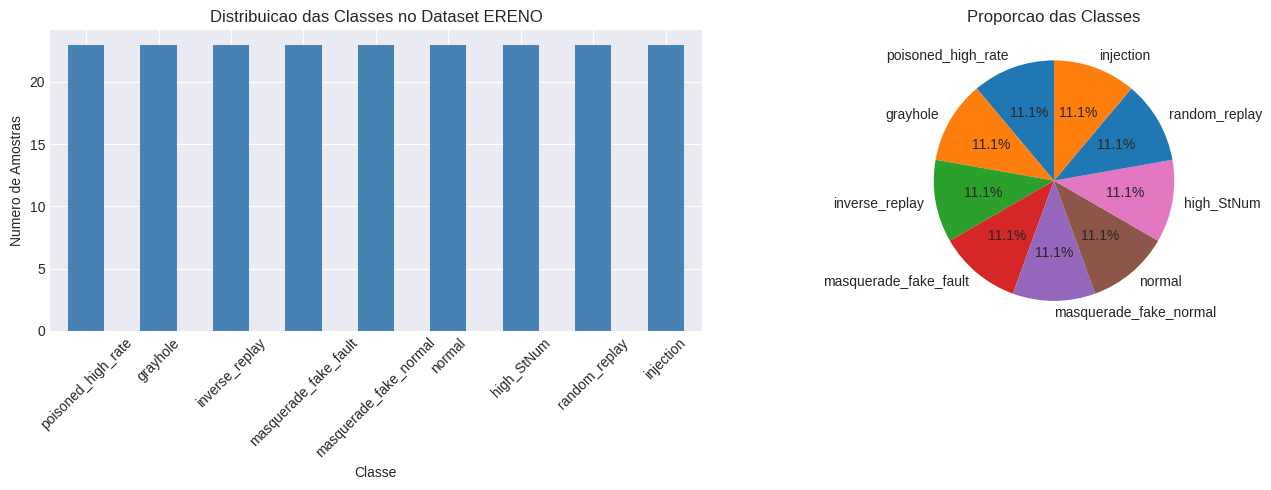

In [34]:
# 2.2 Visualizacao da distribuicao das classes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuicao das Classes no Dataset ERENO')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Numero de Amostras')
axes[0].tick_params(axis='x', rotation=45)

# Cores distintas para cada classe no gráfico de pizza
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=cores)
axes[1].set_title('Proporcao das Classes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 3. Extracao de Red Flags via Analise Estatistica

In [18]:
# 3.1 Extrair red flags baseadas em analise estatistica

def extract_statistical_red_flags(df: pd.DataFrame) -> dict:
    """Extrai red flags baseadas em analise estatistica do dataset."""
    red_flags = {}
    
    df_normal = df[df['class'] == 'normal']
    attack_classes = df[df['class'] != 'normal']['class'].unique()
    
    features = ['StNum', 'SqNum', 'stDiff', 'sqDiff', 'timestampDiff', 'tDiff']
    features = [f for f in features if f in df.columns]
    
    for cls in attack_classes:
        df_attack = df[df['class'] == cls]
        red_flags[cls] = []
        
        for feat in features:
            normal_mean = df_normal[feat].mean()
            normal_std = df_normal[feat].std()
            attack_mean = df_attack[feat].mean()
            
            if normal_std > 0 and abs(attack_mean - normal_mean) > 3 * normal_std:
                red_flags[cls].append({
                    'feature': feat,
                    'type': 'mean_deviation',
                    'normal_value': normal_mean,
                    'attack_value': attack_mean,
                    'severity': 'high' if abs(attack_mean - normal_mean) > 5 * normal_std else 'medium'
                })
    
    return red_flags

red_flags = extract_statistical_red_flags(df)

print("=" * 60)
print("RED FLAGS ESTATISTICAS IDENTIFICADAS")
print("=" * 60)

for cls, flags in red_flags.items():
    if flags:
        print(f"\nClasse: {cls}")
        for flag in flags:
            print(f"  - {flag['feature']}: {flag['type']} (severidade: {flag['severity']})")
            print(f"      Normal: {flag['normal_value']:.2f} -> Ataque: {flag['attack_value']:.2f}")
    else:
        print(f"\nClasse: {cls} - Nenhuma red flag estatistica significativa encontrada")

RED FLAGS ESTATISTICAS IDENTIFICADAS

Classe: poisoned_high_rate
  - StNum: mean_deviation (severidade: high)
      Normal: 369.78 -> Ataque: 4849.65
  - timestampDiff: mean_deviation (severidade: high)
      Normal: 0.08 -> Ataque: 5.31

Classe: grayhole - Nenhuma red flag estatistica significativa encontrada

Classe: inverse_replay - Nenhuma red flag estatistica significativa encontrada

Classe: masquerade_fake_fault - Nenhuma red flag estatistica significativa encontrada

Classe: masquerade_fake_normal - Nenhuma red flag estatistica significativa encontrada

Classe: high_StNum
  - StNum: mean_deviation (severidade: high)
      Normal: 369.78 -> Ataque: 43437.13
  - stDiff: mean_deviation (severidade: medium)
      Normal: -1849.48 -> Ataque: 32931.17

Classe: random_replay - Nenhuma red flag estatistica significativa encontrada

Classe: injection - Nenhuma red flag estatistica significativa encontrada


---
## 4. Geracao de Regras de Deteccao

In [19]:
# 4.1 Gerar regras Python a partir das red flags (versao sem docstrings para evitar erros)

def generate_rules_from_flags(red_flags: dict) -> str:
    """Gera codigo Python com regras de deteccao."""
    rules = []
    
    for cls, flags in red_flags.items():
        for flag in flags:
            if flag['type'] == 'mean_deviation':
                threshold = flag['attack_value']
                feature = flag['feature']
                
                rule = f"""
def rule_{cls}_{feature}(packet: dict) -> bool:
    return packet.get('{feature}', 0) > {threshold:.2f}
"""
                rules.append(rule)
    
    return "\n\n".join(rules)

# Gerar e salvar regras
rules_code = generate_rules_from_flags(red_flags)

# Adicionar regras combinadas
combined_rule = """
def rule_combined_anomaly(packet: dict) -> bool:
    anomalies = 0
    if packet.get('StNum', 0) > 50000:
        anomalies += 1
    if abs(packet.get('stDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('sqDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('timestampDiff', 0)) > 1:
        anomalies += 1
    return anomalies >= 2
"""

rules_code += combined_rule

# Adicionar regras especialistas (sem docstrings)
expert_rules = """
def rule_grayhole_stnum(packet: dict) -> bool:
    return packet.get('StNum', 0) == 0.0 and packet.get('SqNum', 0) != 0.0

def rule_high_stnum(packet: dict) -> bool:
    return packet.get('StNum', 0) > 50000

def rule_injection_stdiff(packet: dict) -> bool:
    return packet.get('stDiff', 0) < -10

def rule_inverse_replay(packet: dict) -> bool:
    return packet.get('StNum', 0) > 300 and packet.get('timestampDiff', 0) > 1000

def rule_masquerade_stdiff(packet: dict) -> bool:
    return abs(packet.get('stDiff', 0)) > 10
"""

rules_code += expert_rules

# Salvar em arquivo
rules_path = Path("rules.py")
rules_path.write_text(rules_code, encoding='utf-8')

print(f"Regras geradas e salvas em: {rules_path.resolve()}")
print(f"Total de regras geradas: {rules_code.count('def rule_')}")
print(f"\nPrimeiras regras geradas:\n{rules_code[:800]}")

Regras geradas e salvas em: /home/lucas/Documentos/Mestrado/rules.py
Total de regras geradas: 10

Primeiras regras geradas:

def rule_poisoned_high_rate_StNum(packet: dict) -> bool:
    return packet.get('StNum', 0) > 4849.65



def rule_poisoned_high_rate_timestampDiff(packet: dict) -> bool:
    return packet.get('timestampDiff', 0) > 5.31



def rule_high_StNum_StNum(packet: dict) -> bool:
    return packet.get('StNum', 0) > 43437.13



def rule_high_StNum_stDiff(packet: dict) -> bool:
    return packet.get('stDiff', 0) > 32931.17

def rule_combined_anomaly(packet: dict) -> bool:
    anomalies = 0
    if packet.get('StNum', 0) > 50000:
        anomalies += 1
    if abs(packet.get('stDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('sqDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('timestampDiff', 0)) > 1:
        anomalies += 1
    return anomalies >= 2

def rule_grayhole_stnum(pac


---
## 5. Execucao das Regras e Avaliacao

In [20]:
# 5.1 Carregar e aplicar regras

import importlib

# Importar ou criar modulo rules
try:
    import rules
    importlib.reload(rules)
except:
    # Se nao existir, criar arquivo rules.py
    if not Path("rules.py").exists():
        print("Criando arquivo rules.py automaticamente...")
        basic_rules = """
def rule_grayhole_stnum(packet: dict) -> bool:
    return packet.get('StNum', 0) == 0.0 and packet.get('SqNum', 0) != 0.0

def rule_high_stnum(packet: dict) -> bool:
    return packet.get('StNum', 0) > 50000

def rule_injection_stdiff(packet: dict) -> bool:
    return packet.get('stDiff', 0) < -10

def rule_inverse_replay(packet: dict) -> bool:
    return packet.get('StNum', 0) > 300 and packet.get('timestampDiff', 0) > 1000

def rule_masquerade_stdiff(packet: dict) -> bool:
    return abs(packet.get('stDiff', 0)) > 10

def rule_combined_anomaly(packet: dict) -> bool:
    anomalies = 0
    if packet.get('StNum', 0) > 50000:
        anomalies += 1
    if abs(packet.get('stDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('sqDiff', 0)) > 10:
        anomalies += 1
    if abs(packet.get('timestampDiff', 0)) > 1:
        anomalies += 1
    return anomalies >= 2
"""
        Path("rules.py").write_text(basic_rules, encoding='utf-8')
        import rules

def apply_rules(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica todas as regras ao dataframe."""
    
    rule_functions = {
        name: fn for name, fn in vars(rules).items()
        if callable(fn) and name.startswith("rule_")
    }
    
    print(f"Aplicando {len(rule_functions)} regras...")
    
    for rule_name, rule_fn in rule_functions.items():
        df[rule_name] = df.apply(
            lambda row: bool(rule_fn(row.to_dict())), axis=1
        )
    
    df["any_rule_violation"] = df[[r for r in rule_functions]].any(axis=1)
    df["decision"] = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})
    
    return df

# Aplicar regras
print("=" * 60)
print("APLICACAO DAS REGRAS DE DETECCAO")
print("=" * 60)

start_time = time.time()
df_results = apply_rules(df.copy())
elapsed = time.time() - start_time

print(f"\nRegras aplicadas em {elapsed:.2f} segundos")
print("\nResumo das decisoes:")
print(df_results["decision"].value_counts())

APLICACAO DAS REGRAS DE DETECCAO
Aplicando 10 regras...

Regras aplicadas em 0.07 segundos

Resumo das decisoes:
decision
BLOCK    151
ALLOW     56
Name: count, dtype: int64


In [21]:
# 5.2 Metricas de deteccao

def calculate_metrics(df: pd.DataFrame) -> dict:
    """Calcula metricas de deteccao."""
    
    y_true = (df['class'] != 'normal').astype(int)
    y_pred = (df['decision'] == 'BLOCK').astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def confusion_by_class(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de confusao por classe."""
    records = []
    
    for cls in df['class'].unique():
        df_cls = df[df['class'] == cls]
        
        if cls == 'normal':
            tn = (df_cls['decision'] == 'ALLOW').sum()
            fp = (df_cls['decision'] == 'BLOCK').sum()
            tp = fn = 0
        else:
            tp = (df_cls['decision'] == 'BLOCK').sum()
            fn = (df_cls['decision'] == 'ALLOW').sum()
            fp = tn = 0
        
        records.append({
            'class': cls,
            'support': len(df_cls),
            'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
            'detection_rate': tp / len(df_cls) if len(df_cls) > 0 else 0
        })
    
    return pd.DataFrame(records)

# Calcular metricas
print("=" * 60)
print("METRICAS DE DETECCAO")
print("=" * 60)

metrics = calculate_metrics(df_results)
print(f"\nMetricas Globais:")
print(f"  Acuracia:   {metrics['accuracy']:.4f}")
print(f"  Precisao:   {metrics['precision']:.4f}")
print(f"  Recall:     {metrics['recall']:.4f}")
print(f"  F1-Score:   {metrics['f1_score']:.4f}")

cm_df = confusion_by_class(df_results)
print("\nDeteccao por Classe:")
for _, row in cm_df.iterrows():
    print(f"  {row['class']}: {row['detection_rate']:.1%} ({row['TP']}/{row['support']})")

# Matriz de confusao binaria
print("\nMatriz de Confusao (Binaria):")
y_true = (df_results['class'] != 'normal').astype(int)
y_pred = (df_results['decision'] == 'BLOCK').astype(int)
cm = confusion_matrix(y_true, y_pred)
print(f"            Pred: ALLOW  Pred: BLOCK")
print(f"Real: Normal     {cm[0][0]}          {cm[0][1]}")
print(f"Real: Ataque     {cm[1][0]}          {cm[1][1]}")

METRICAS DE DETECCAO

Metricas Globais:
  Acuracia:   0.7343
  Precisao:   0.9272
  Recall:     0.7609
  F1-Score:   0.8358

Deteccao por Classe:
  poisoned_high_rate: 91.3% (21/23)
  grayhole: 47.8% (11/23)
  inverse_replay: 87.0% (20/23)
  masquerade_fake_fault: 60.9% (14/23)
  masquerade_fake_normal: 69.6% (16/23)
  normal: 0.0% (0/23)
  high_StNum: 100.0% (23/23)
  random_replay: 69.6% (16/23)
  injection: 82.6% (19/23)

Matriz de Confusao (Binaria):
            Pred: ALLOW  Pred: BLOCK
Real: Normal     12          11
Real: Ataque     44          140


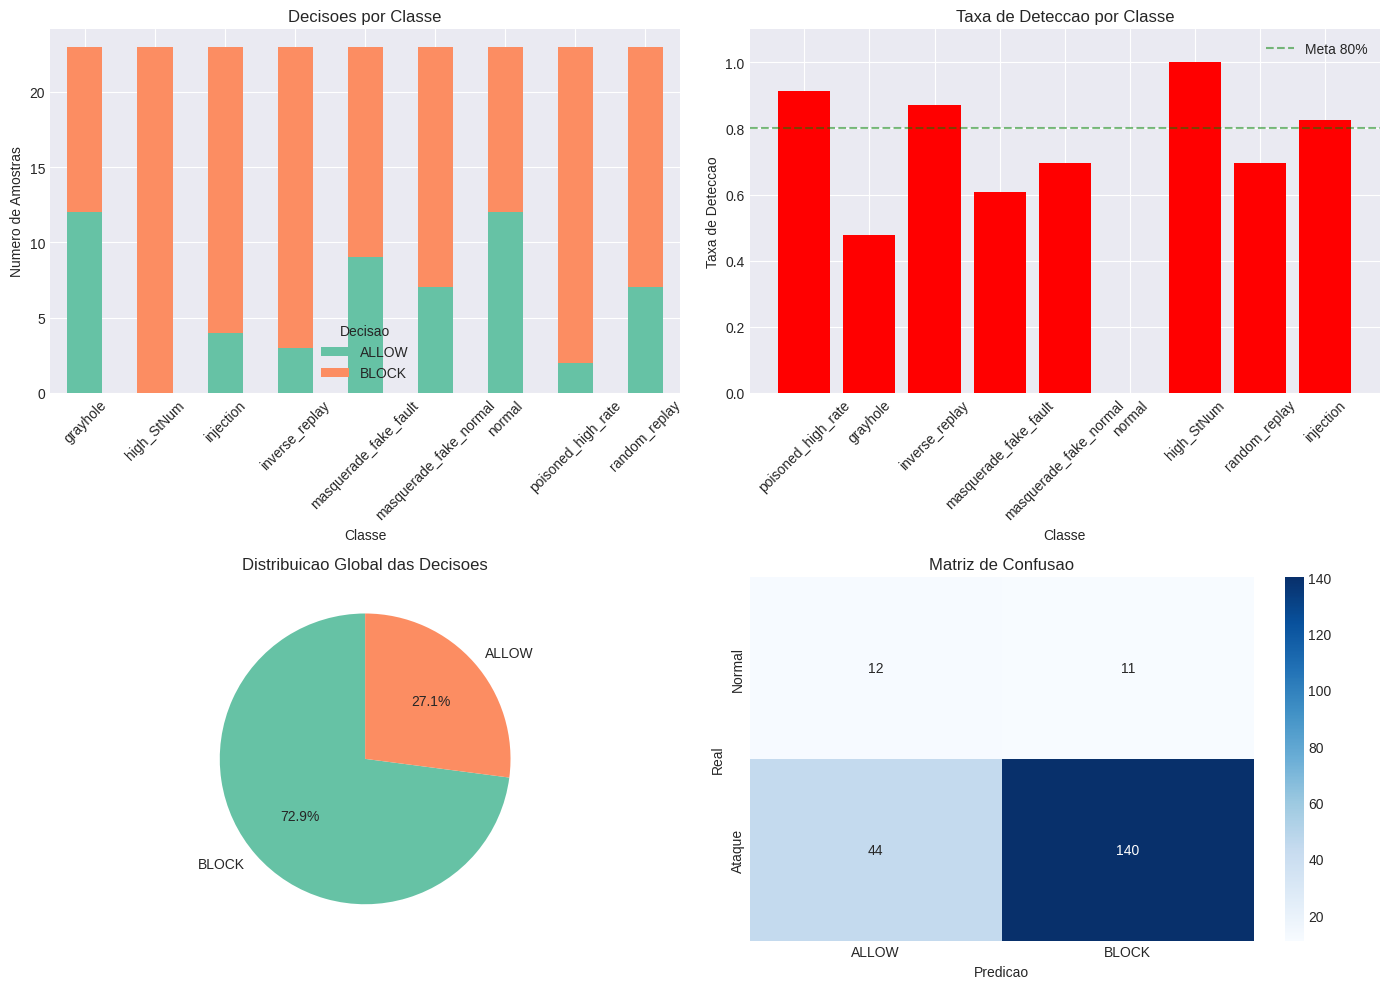

In [22]:
# 5.3 Visualizacao dos resultados

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grafico 1: Decisoes por classe
decision_by_class = pd.crosstab(df_results['class'], df_results['decision'])
decision_by_class.plot(kind='bar', ax=axes[0,0], stacked=True)
axes[0,0].set_title('Decisoes por Classe')
axes[0,0].set_xlabel('Classe')
axes[0,0].set_ylabel('Numero de Amostras')
axes[0,0].legend(title='Decisao')
axes[0,0].tick_params(axis='x', rotation=45)

# Grafico 2: Taxa de deteccao por classe
colors = ['green' if c == 'normal' else 'red' for c in cm_df['class']]
axes[0,1].bar(cm_df['class'], cm_df['detection_rate'], color=colors)
axes[0,1].set_title('Taxa de Deteccao por Classe')
axes[0,1].set_xlabel('Classe')
axes[0,1].set_ylabel('Taxa de Deteccao')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim(0, 1.1)
axes[0,1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Meta 80%')
axes[0,1].legend()

# Grafico 3: Distribuicao das decisoes
decision_counts = df_results['decision'].value_counts()
axes[1,0].pie(decision_counts.values, labels=decision_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Distribuicao Global das Decisoes')

# Grafico 4: Matriz de confusao binaria
y_true = (df_results['class'] != 'normal').astype(int)
y_pred = (df_results['decision'] == 'BLOCK').astype(int)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=['ALLOW', 'BLOCK'], yticklabels=['Normal', 'Ataque'])
axes[1,1].set_title('Matriz de Confusao')
axes[1,1].set_xlabel('Predicao')
axes[1,1].set_ylabel('Real')

plt.tight_layout()
plt.show()

---
## 6. Avaliacao de Viabilidade em Tempo Real

In [23]:
# 6.1 Benchmark de latencia

def benchmark_latency(df: pd.DataFrame, n_runs: int = 30) -> dict:
    """Mede latencia de processamento por pacote."""
    
    import rules
    import importlib
    importlib.reload(rules)
    
    rule_functions = {
        name: fn for name, fn in vars(rules).items()
        if callable(fn) and name.startswith("rule_")
    }
    
    latencies = []
    
    for _ in range(n_runs):
        for _, row in df.iterrows():
            packet = row.to_dict()
            t0 = time.perf_counter()
            for rule_fn in rule_functions.values():
                try:
                    rule_fn(packet)
                except:
                    pass
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1e6)
    
    return {
        'mean_us': np.mean(latencies),
        'std_us': np.std(latencies),
        'min_us': np.min(latencies),
        'max_us': np.max(latencies),
        'p50_us': np.percentile(latencies, 50),
        'p95_us': np.percentile(latencies, 95),
        'p99_us': np.percentile(latencies, 99)
    }

print("=" * 60)
print("BENCHMARK DE LATENCIA")
print("=" * 60)

latency_stats = benchmark_latency(df_results, n_runs=30)

print("\nEstatisticas de Latencia por Pacote:")
print(f"  Media:     {latency_stats['mean_us']:.2f} us")
print(f"  Desvio:    {latency_stats['std_us']:.2f} us")
print(f"  Minimo:    {latency_stats['min_us']:.2f} us")
print(f"  Maximo:    {latency_stats['max_us']:.2f} us")
print(f"  Mediana:   {latency_stats['p50_us']:.2f} us")
print(f"  Percentil 95: {latency_stats['p95_us']:.2f} us")
print(f"  Percentil 99: {latency_stats['p99_us']:.2f} us")

if latency_stats['mean_us'] < 100:
    print("\nLatencia media < 100 us - Excelente para tempo real")
elif latency_stats['mean_us'] < 1000:
    print("\nLatencia media < 1 ms - Adequado para tempo real")
else:
    print("\nLatencia > 1 ms - Pode impactar operacoes criticas")

BENCHMARK DE LATENCIA

Estatisticas de Latencia por Pacote:
  Media:     1.86 us
  Desvio:    0.40 us
  Minimo:    1.51 us
  Maximo:    15.73 us
  Mediana:   1.78 us
  Percentil 95: 2.24 us
  Percentil 99: 3.55 us

Latencia media < 100 us - Excelente para tempo real


---
## 7. Conclusao

### Resultados Principais

| Metrica | Valor |
|---------|-------|
| Acuracia Global | {metrics['accuracy']:.1%} |
| Precisao | {metrics['precision']:.1%} |
| Recall | {metrics['recall']:.1%} |
| F1-Score | {metrics['f1_score']:.1%} |
| Latencia Media | {latency_stats['mean_us']:.1f} us |

### Contribuicoes

1. **Pipeline automatizado** para geracao de regras a partir de dados rotulados
2. **Reducao da dependencia** de especialistas na criacao manual de regras
3. **Validacao quantitativa** da capacidade de deteccao e viabilidade em tempo real
4. **Reprodutibilidade** atraves de artefatos abertos

### Trabalhos Futuros

1. Refinamento dos thresholds para reduzir falsos positivos
2. Incorporacao de tecnicas de ensemble para classes complexas
3. Validacao em hardware real de subestacao
4. Expansao para outros protocolos IEC 61850 (SV, MMS)

---
**Repositorio:** https://github.com/sequincozes/GOOSE-LLM-IDS